In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
df = pd.read_csv("data/sales_data.csv")

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1000
Columns: 13


In [7]:
df.head()

,Order_ID,Order_Date,Customer,Region,Category,Product,Quantity,Unit_Price,Sales,Cost,Profit,Customer_Segment,Payment_Mode
0,ORD00219,2024-01-01,Customer 119,East,Electronics,Smartphone,9,40892,368028,288589.68,79438.32,Corporate,Credit Card
1,ORD00072,2024-01-01,Customer 190,North,Electronics,Headphones,8,5924,47392,35814.02,11577.98,Small Business,Cash
2,ORD00924,2024-01-02,Customer 101,North,Furniture,Bookshelf,9,8071,72639,50245.46,22393.54,Corporate,Credit Card
3,ORD00232,2024-01-03,Customer 85,South,Office Supplies,Pen Set,3,209,627,445.57,181.43,Corporate,Debit Card
4,ORD00489,2024-01-03,Customer 242,North,Furniture,Table,4,8278,33112,20538.03,12573.97,Consumer,Debit Card


In [8]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
Order_ID            0
Order_Date          0
Customer            0
Region              0
Category            0
Product             0
Quantity            0
Unit_Price          0
Sales               0
Cost                0
Profit              0
Customer_Segment    0
Payment_Mode        0
dtype: int64

Duplicate Rows: 0

Data Types:
Order_ID                       str
Order_Date          datetime64[us]
Customer                       str
Region                         str
Category                       str
Product                        str
Quantity                     int64
Unit_Price                   int64
Sales                        int64
Cost                       float64
Profit                     float64
Customer_Segment               str
Payment_Mode                   str
dtype: object


In [9]:
df.describe()

,Order_Date,Quantity,Unit_Price,Sales,Cost,Profit
count,1000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,2024-12-22 10:40:48,5.013000,16491.997000,84389.79900,57194.960850,27194.838150
min,2024-01-01 00:00:00,1.000000,51.000000,51.00000,29.750000,21.250000
25%,2024-06-23 18:00:00,3.000000,446.500000,2570.50000,1749.995000,845.170000
50%,2024-12-22 12:00:00,5.000000,10588.000000,45047.00000,29375.925000,13928.630000
75%,2025-06-09 06:00:00,7.000000,20661.000000,101248.50000,69923.965000,33108.332500
max,2025-12-30 00:00:00,9.000000,89353.000000,785628.00000,593072.450000,288577.180000
std,NaN,2.648366,19783.699398,122477.75161,84534.441046,40100.453459


In [10]:
# Key Business KPIs

total_sales = df["Sales"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_quantity = df["Quantity"].sum()

average_order_value = total_sales / total_orders
profit_margin = (total_profit / total_sales) * 100

print("===== BUSINESS KPIs =====")
print(f"Total Sales       : ₹{total_sales:,.2f}")
print(f"Total Cost        : ₹{total_cost:,.2f}")
print(f"Total Profit      : ₹{total_profit:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Quantity    : {total_quantity:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Profit Margin     : {profit_margin:.2f}%")

===== BUSINESS KPIs =====
Total Sales       : ₹84,389,799.00
Total Cost        : ₹57,194,960.85
Total Profit      : ₹27,194,838.15
Total Orders      : 1,000
Total Quantity    : 5,013
Average Order Value: ₹84,389.80
Profit Margin     : 32.23%


In [11]:
monthly_sales = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Order_Date"] = monthly_sales["Order_Date"].astype(str)

monthly_sales.head()

,Order_Date,Sales
0,2024-01,6094912
1,2024-02,2828920
2,2024-03,2428272
3,2024-04,2876191
4,2024-05,4154116


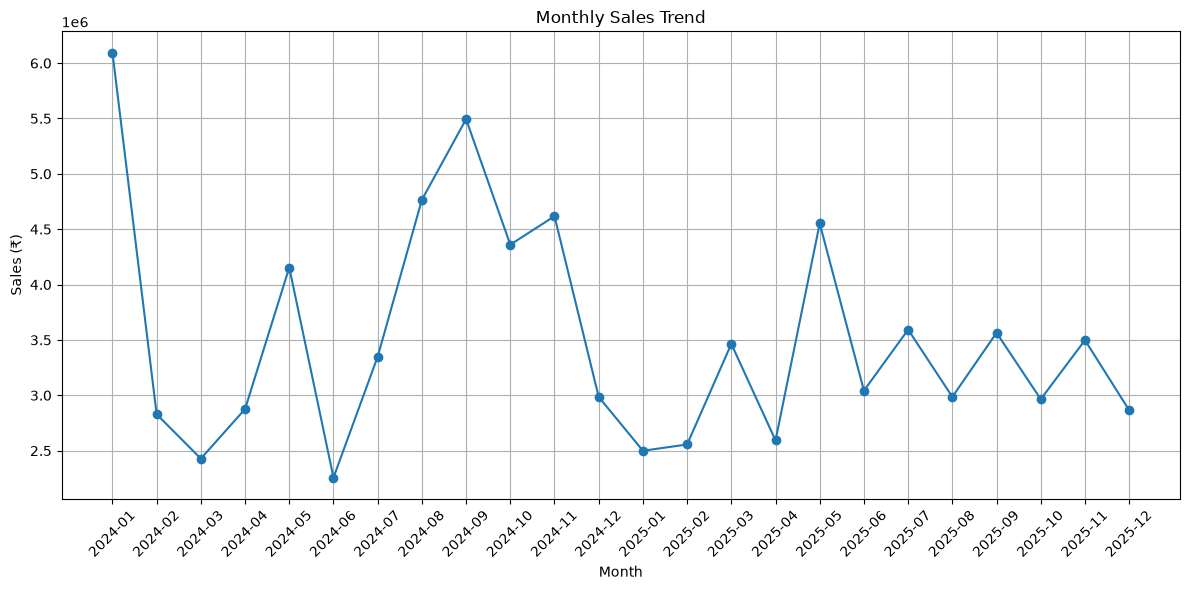

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Order_Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

Region
North    24137592
South    20762680
East     19906481
West     19583046
Name: Sales, dtype: int64


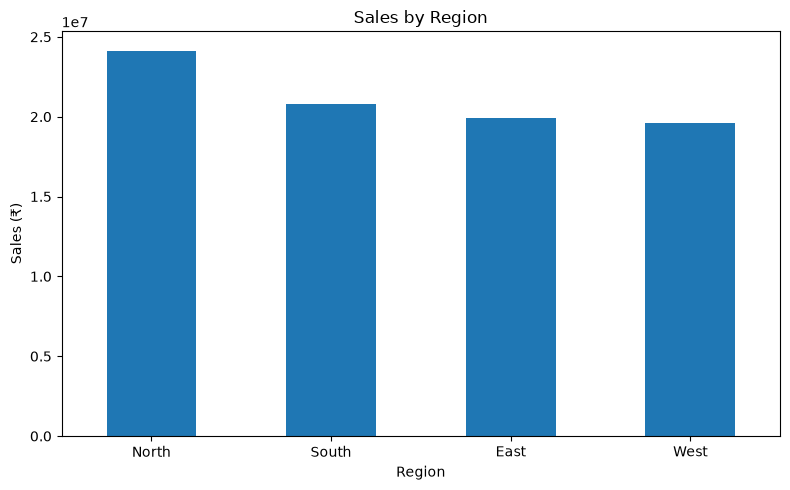

In [14]:
region_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Electronics        57341252
Furniture          20959823
Office Supplies     6088724
Name: Sales, dtype: int64


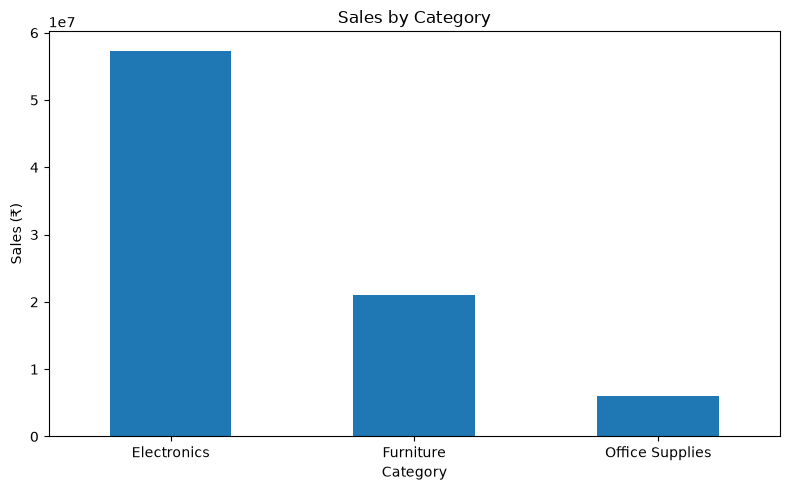

In [16]:
category_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [17]:
top_products = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product
Laptop          28120915
Smartphone      15517157
Tablet          11815621
Desk             7605160
Printer          5836299
Office Chair     4919868
Table            4610406
Bookshelf        3824389
Headphones       1887559
Pen Set           121618
Name: Sales, dtype: int64


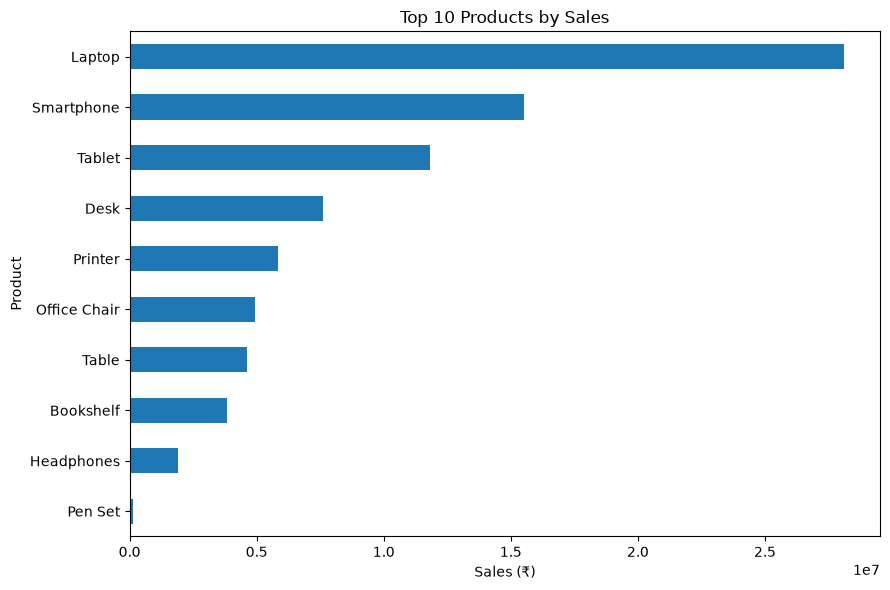

In [18]:
top_products.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales (₹)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [19]:
profit_by_region = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("Profit by Region:")
print(profit_by_region)

Profit by Region:
Region
North    7753931.03
South    6896324.29
East     6460575.50
West     6084007.33
Name: Profit, dtype: float64


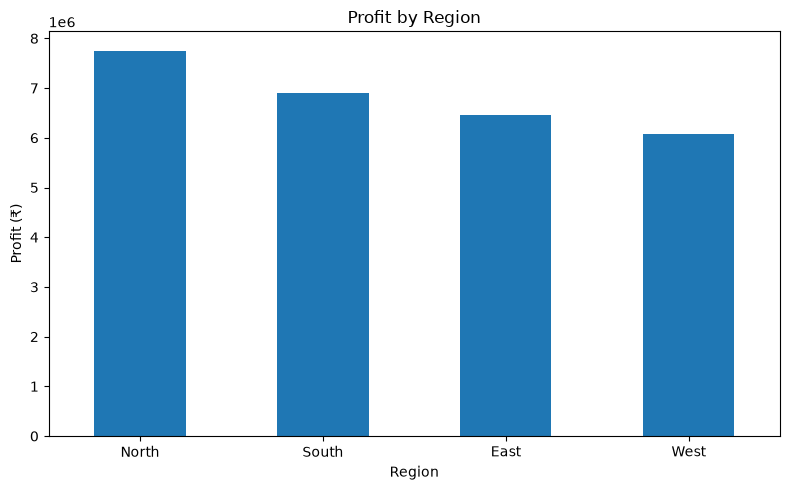

In [20]:
profit_by_region.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [21]:
profit_by_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("Profit by Category:")
print(profit_by_category)

Profit by Category:
Category
Electronics        18396139.55
Furniture           6805839.45
Office Supplies     1992859.15
Name: Profit, dtype: float64


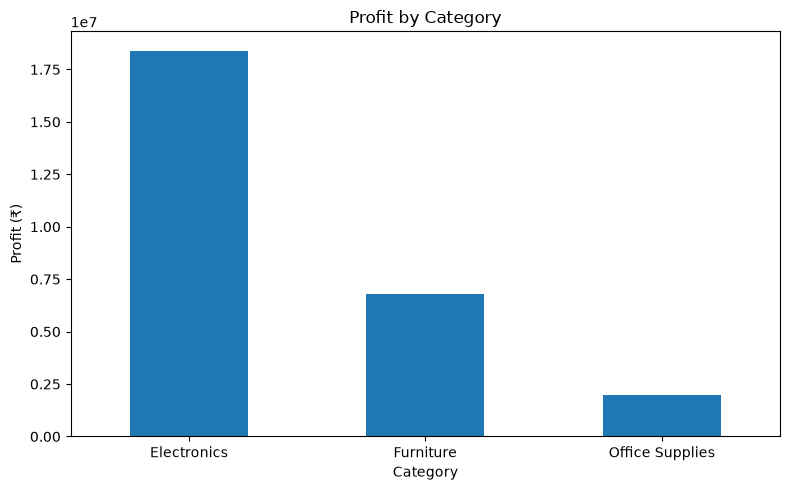

In [22]:
profit_by_category.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
segment_analysis = (
    df.groupby("Customer_Segment")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order_ID", "nunique")
    )
    .sort_values("Sales", ascending=False)
)

segment_analysis

,Sales,Profit,Orders
Customer_Segment,,,
Corporate,31130697,9871439.89,344
Consumer,26997005,8681615.52,325
Small Business,26262097,8641782.74,331


In [24]:
payment_analysis = (
    df.groupby("Payment_Mode")
    .agg(
        Sales=("Sales", "sum"),
        Orders=("Order_ID", "nunique")
    )
    .sort_values("Sales", ascending=False)
)

payment_analysis

,Sales,Orders
Payment_Mode,,
Cash,22573280,262
Credit Card,22438211,246
Debit Card,19724478,252
UPI,19653830,240


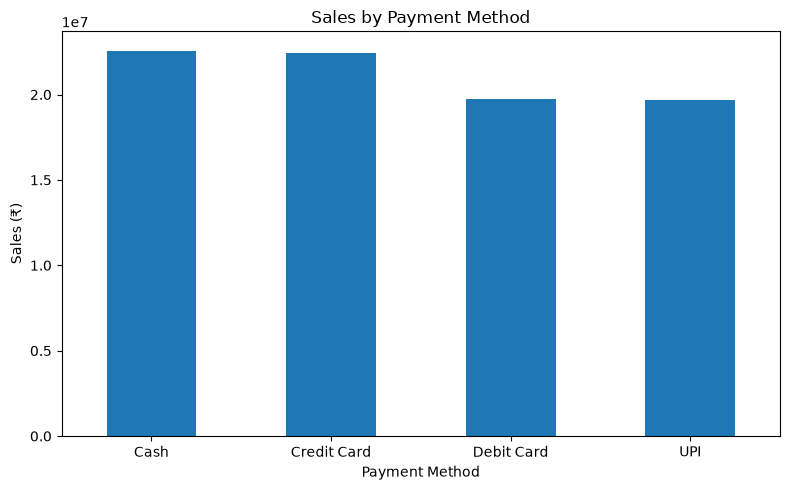

In [25]:
payment_analysis["Sales"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [26]:
top_profit_products = (
    df.groupby("Product")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Profit:")
print(top_profit_products)

Top 10 Products by Profit:
Product
Laptop          9010380.61
Smartphone      4852562.72
Tablet          3900330.44
Desk            2374165.76
Printer         1908481.04
Office Chair    1660774.20
Table           1510675.36
Bookshelf       1260224.13
Headphones       632865.78
Pen Set           39601.03
Name: Profit, dtype: float64


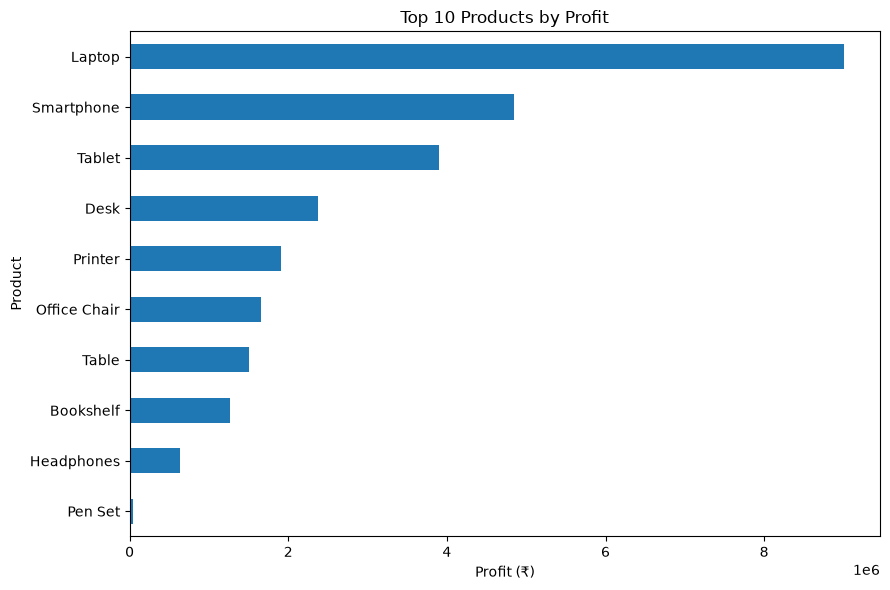

In [27]:
top_profit_products.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit (₹)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [28]:
category_profitability = (
    df.groupby("Category")
    .agg(
        Sales=("Sales", "sum"),
        Cost=("Cost", "sum"),
        Profit=("Profit", "sum")
    )
)

category_profitability["Profit_Margin"] = (
    category_profitability["Profit"]
    / category_profitability["Sales"]
) * 100

category_profitability = category_profitability.sort_values(
    "Profit_Margin",
    ascending=False
)

category_profitability

,Sales,Cost,Profit,Profit_Margin
Category,,,,
Office Supplies,6088724,4095864.85,1992859.15,32.730325
Furniture,20959823,14153983.55,6805839.45,32.470882
Electronics,57341252,38945112.45,18396139.55,32.081859
